In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime, timedelta


# 1. Load Data
## 1.1 Recent Data
### Data Description
- **Date**: Timestamp for each record, indicating the exact date and time the data was captured.
- **T1 to T15**:
  - **Description**: Temperature measurements from 15 different sensors.
  - **Unit**: Degrees Celsius (°C).
  - **Purpose**: To monitor temperature variations across different locations or stages within the environment or process.
- **F1, F2, F3**:
  - **Description**: Flow rates from three sensors.
  - **Unit**: Liters per second (L/s) or cubic meters per second (m³/s), depending on the scale of measurement.
  - **Purpose**: To track the flow of fluids (could be air, water, or other gases/liquids) through different parts of the system.
- **SR**:
  - **Description**: Solar radiation measurement.
  - **Unit**: Watts per square meter (W/m²).
  - **Purpose**: To measure the intensity of solar radiation, which is crucial for applications such as solar power generation, agricultural planning, and environmental monitoring.

In [5]:
# test code
column_names = ['Date+T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'F1', 'F2', 'F3', 'SR', 'A', 'Circ pump counter']
data = pd.read_csv('data_2024-06-24.csv', header=None, names=column_names).reset_index().rename(columns={'index': 'Date'})
cols = ['Date', 'SR']
data = data[cols]
data 

,Date,SR
0,2024-06-24 00:00:00,SR1:91.64
1,2024-06-24 00:00:05,SR1:91.16
2,2024-06-24 00:00:11,SR1:90.49
3,2024-06-24 00:00:16,SR1:89.19
4,2024-06-24 00:00:21,SR1:87.46
...,...,...
15886,2024-06-24 23:59:34,SR1:85.42
15887,2024-06-24 23:59:39,SR1:86.68
15888,2024-06-24 23:59:44,SR1:88.11
15889,2024-06-24 23:59:50,SR1:90.69


In [6]:
# load recent SR data
start_date = datetime(2024, 5, 20)
end_date = datetime(2024, 6, 25)

# col names
column_names = ['Date+T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'F1', 'F2', 'F3', 'SR', 'A', 'Circ pump counter']

dataframes = {}
current_date = start_date

while current_date <= end_date:
    file_name = f'data_{current_date.strftime("%Y-%m-%d")}.csv'
    date_key = current_date.strftime("%Y-%m-%d")

    try:
        # load the data without using the first row as headers and specify the column names
        data = pd.read_csv(file_name, header=None, names=column_names)

        # check if 'T1' is concatenated with 'Date' and handle accordingly
        if '-' in data.iloc[0, 0]:
            # split 'Date+T1' into two separate columns 'Date' and 'T1'
            new_cols = data['Date+T1'].str.split(' T1:', expand=True)
            data['Date'] = new_cols[0]
            data['T1'] = new_cols[1].astype(float)
            # make sure 'T1' is correctly placed without affecting other columns
            cols = ['Date', 'SR']
            data = data[cols]
        else:
            # separate 'Date' and 'T1' if not concatenated
            data= data.reset_index().rename(columns={'index': 'Date'})
            cols = ['Date', 'SR']
            data = data[cols]

        # clean SR
        data['SR'] = data['SR'].str.split(':').str[1].astype(float)
        # drop NaNs
        data.dropna(inplace=True)

        # store the DataFrame in the dictionary with the date as the key
        dataframes[date_key] = data
        
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

    current_date += timedelta(days=1)


In [7]:
# concat all recent data
recent_data = pd.concat(dataframes.values())
recent_data['Date'] = pd.to_datetime(recent_data['Date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
recent_data['Dates'] = recent_data['Date'].dt.date
recent_data['Time'] = recent_data['Date'].dt.time
recent_data = recent_data[['Dates', 'Time', 'SR']].dropna().sort_values(by=['Dates'])
recent_data 

,Dates,Time,SR
0,2024-05-20,20:58:45,82.24
1240,2024-05-20,23:00:15,84.67
1239,2024-05-20,23:00:09,84.71
1238,2024-05-20,23:00:03,84.80
1237,2024-05-20,22:59:58,84.99
...,...,...,...
5286,2024-06-25,07:59:56,123.08
5287,2024-06-25,08:00:02,123.36
5288,2024-06-25,08:00:07,123.28
5290,2024-06-25,08:00:18,123.30


## 1.2 Backup data

In [8]:
# load backup data
def process_backup_data(file_path):
    column_names = ['Date+T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'F1', 'F2', 'F3', 'SR', 'A', 'Circ pump counter']
    data = pd.read_csv(file_path, header=None, names=column_names, skiprows=1)
    data = data[['Date+T1', 'SR']]
    new_cols = data['Date+T1'].str.split(' T1:', expand=True)
    data['Date'] = new_cols[0]
    data.drop(columns=['Date+T1'], inplace=True)
    data['SR'] = data['SR'].str.split(':').str[1].astype(float)
    return data


In [9]:
# concat all backup data 
backup0 = 'data_backup0.csv'
backup1 = 'data_backup1.csv'
backup2 = 'data_backup2.csv'
backup3 = 'data_backup3.csv'
backup4 = 'data_backup4.csv'
twentyfour_apr_may = process_backup_data(backup0)
twentyfour_mar_apr = process_backup_data(backup1)
twentyfour_mar = process_backup_data(backup2)
twentyfour_mar_mid = process_backup_data(backup3).drop(0)
twentythree_sep_mar = process_backup_data(backup4)

all_backup_data = pd.concat([
    twentyfour_apr_may,
    twentyfour_mar_apr,
    twentyfour_mar,
    twentyfour_mar_mid,
    twentythree_sep_mar
], ignore_index=True)

In [10]:
# seperate time from date
all_backup_data['Date'] = pd.to_datetime(all_backup_data['Date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
all_backup_data['Dates'] = all_backup_data['Date'].dt.date
all_backup_data['Time'] = all_backup_data['Date'].dt.time
all_backup_data = all_backup_data[['Dates', 'Time', 'SR']].dropna().sort_values(by=['Dates'])
all_backup_data 

,Dates,Time,SR
795781,2023-09-22,17:26:14,133.17
795790,2023-09-22,17:27:03,154.98
795789,2023-09-22,17:26:58,153.22
795788,2023-09-22,17:26:52,149.67
795787,2023-09-22,17:26:47,144.47
...,...,...,...
415001,2024-05-17,06:12:54,88.20
415002,2024-05-17,06:12:59,90.38
415003,2024-05-17,06:13:05,84.84
414983,2024-05-17,06:11:08,84.75


In [11]:
recent_data.shape

(573587, 3)

In [36]:
all_backup_data.groupby('Dates')['SR'].sum()

Dates
2023-09-22      12256.92
2023-10-06      18039.51
2023-10-12      45050.31
2023-11-01       4977.13
2024-02-20     299578.38
                 ...    
2024-05-13    1857793.51
2024-05-14    1906887.60
2024-05-15    2080273.64
2024-05-16    1732280.85
2024-05-17    1279259.43
Name: SR, Length: 83, dtype: float64

In [13]:
# all SR data without zip
without_zip_data = pd.concat([recent_data, all_backup_data], ignore_index=True)
without_zip_data.groupby('Dates')['SR'].max()

Dates
2023-09-22     156.41
2023-10-06     203.26
2023-10-12     401.61
2023-11-01      83.63
2024-02-20     362.01
               ...   
2024-06-21     870.44
2024-06-22     489.85
2024-06-23    1040.49
2024-06-24     993.09
2024-06-25     769.90
Name: SR, Length: 120, dtype: float64

## 1.3 Weather Data

### Data Description
**Heat Deg Days (°C)**: Heating degree-days for a given day are the number of degrees Celsius that the mean temperature is below 18 °C. If the temperature is equal to or greater than 18 °C, then the number will be zero. For example, a day with a mean temperature of 15.5 °C has 2.5 heating degree-days; a day with a mean temperature of 20.5 °C has zero heating degree-days. Heating degree-days are used primarily to estimate the heating requirements of buildings.

**Cool Deg Days (°C)**: Cooling degree-days for a given day are the number of degrees Celsius that the mean temperature is above 18 °C. If the temperature is equal to or less than 18 °C, then the number will be zero. For example, a day with a mean temperature of 20.5 °C has 2.5 cooling degree-days; a day with a mean temperature of 15.5 °C has zero cooling degree-days. Cooling degree-days are used primarily to estimate the air-conditioning requirements of buildings.

**Snow on Grnd (cm)**: The depth of snow in centimetres (cm) on the ground. The total depth of snow on the ground at the time of the observation is determined in whole centimetres by making a series of measurements and taking the average.

In [14]:
# concat 2023 and 2024 weather data
wheather_data_24 = pd.read_csv('en_climate_daily_BC_1108395_2024_P1D-2.csv')
wheather_data_23 = pd.read_csv('en_climate_daily_BC_1108395_2023_P1D.csv')
weather_data = pd.concat([wheather_data_23, wheather_data_24], ignore_index=True)
weather_data = weather_data.drop(columns = ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Year', 'Month', 'Day', 'Data Quality'])
weather_data = weather_data.drop(columns = filter(lambda x: 'Flag' in x, weather_data.columns)).rename(columns={'Date/Time': 'Dates'})
weather_data

,Dates,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
0,2023-01-01,7.8,2.2,5.0,13.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,2023-01-02,5.0,-0.2,2.4,15.6,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,2023-01-03,5.6,0.2,2.9,15.1,0.0,1.0,0.0,1.0,NaN,9.0,37.0
3,2023-01-04,8.4,2.6,5.5,12.5,0.0,1.5,0.0,1.5,NaN,9.0,39.0
4,2023-01-05,12.2,5.2,8.7,9.3,0.0,2.3,0.0,2.3,NaN,10.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
726,2024-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
727,2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
728,2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
729,2024-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
without_zip_data

,Dates,Time,SR
0,2024-05-20,20:58:45,82.24
1,2024-05-20,23:00:15,84.67
2,2024-05-20,23:00:09,84.71
3,2024-05-20,23:00:03,84.80
4,2024-05-20,22:59:58,84.99
...,...,...,...
1773335,2024-05-17,06:12:54,88.20
1773336,2024-05-17,06:12:59,90.38
1773337,2024-05-17,06:13:05,84.84
1773338,2024-05-17,06:11:08,84.75


In [16]:
without_zip_data.describe()

,SR
count,1.773340e+06
mean,1.481277e+02
std,8.876733e+01
min,3.677000e+01
25%,8.592000e+01
50%,1.212800e+02
75%,1.637500e+02
max,1.164460e+03


### Preprocess 
- Weather + SR
- Caculate the sun angle
- Clean dataframe (sr_weather)
  * Impute Nan in `Total Rain (mm)`, `Total Snow (cm)`, and `Snow on Grnd (cm)` with 0
  * Impute Nan in `Total Precip (mm)` with calculated value
  * Impute Nan in `Dir of Max Gust (10s deg)` and `Spd of Max Gust (km/h)` with median
  * Calculate `Heat Deg Days (°C)` and `Cool Deg Days (°C)` based on temperature data, if not already calculated
  * Discuss the lower limitation -- 80. Do we need to consider this?

In [17]:
# merge weather data and SR data
without_zip_data['Dates'] = pd.to_datetime(without_zip_data['Dates'])
weather_data['Dates'] = pd.to_datetime(weather_data['Dates'])

sr_weather = pd.merge(without_zip_data, weather_data, on='Dates', how='inner').sort_values(by='Dates')
sr_weather

,Dates,Time,SR,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
573587,2023-09-22,17:26:14,133.17,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
573660,2023-09-22,17:22:39,114.77,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
573659,2023-09-22,17:29:27,152.49,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
573658,2023-09-22,17:22:33,118.77,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
573657,2023-09-22,17:20:37,127.22,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563028,2024-06-25,11:59:35,267.40,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,31.0,33.0
563029,2024-06-25,23:57:25,81.29,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,31.0,33.0
563030,2024-06-25,23:54:30,81.33,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,31.0,33.0
563032,2024-06-25,23:57:08,81.42,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,31.0,33.0


In [18]:
# calculate the sun angle
sr_weather['Datetime'] = pd.to_datetime(sr_weather['Dates'].astype(str) + ' ' + sr_weather['Time'].astype(str))

latitude = 49.2827

def get_declination(day_of_year):
    # approximation of the declination of the sun
    return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

# function to calculate hour angle
def get_hour_angle(time, longitude):
    # convert time to total hours
    total_hours = time.hour + time.minute / 60 + time.second / 3600
    # solar noon at the longitude
    solar_noon = 12 - (longitude / 15)
    # hour angle
    return 15 * (total_hours - solar_noon)

# calculate solar elevation
def solar_elevation(latitude, declination, hour_angle):
    # convert degrees to radians
    latitude_rad = np.deg2rad(latitude)
    declination_rad = np.deg2rad(declination)
    hour_angle_rad = np.deg2rad(hour_angle)
    
    # solar elevation calculation
    elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                              np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
    return np.rad2deg(elevation_rad)

# Adding solar elevation to the dataframe
sr_weather['Sun Angle'] = sr_weather['Datetime'].apply(
    lambda x: solar_elevation(
        latitude,
        get_declination(x.timetuple().tm_yday),
        get_hour_angle(x, longitude=-123.1207)  # Vancouver's longitude
    )
)


In [19]:
# Clean sr_weather
# fill NaN for 'Total Rain (mm)' and 'Total Snow (cm)' with 0 where NaN likely means zero precipitation
sr_weather['Total Rain (mm)'].fillna(0, inplace=True)
sr_weather['Total Snow (cm)'].fillna(0, inplace=True)
sr_weather['Snow on Grnd (cm)'].fillna(0, inplace=True)

# replace NaN with median
if 'Dir of Max Gust (10s deg)' in sr_weather.columns and 'Spd of Max Gust (km/h)' in sr_weather.columns:
    sr_weather['Dir of Max Gust (10s deg)'].fillna(sr_weather['Dir of Max Gust (10s deg)'].median(), inplace=True)
    sr_weather['Spd of Max Gust (km/h)'].fillna(sr_weather['Spd of Max Gust (km/h)'].median(), inplace=True)

sr_weather['Total Precip (mm)'] = sr_weather.apply(
    lambda row: row['Total Rain (mm)'] if pd.isna(row['Total Precip (mm)']) and row['Total Snow (cm)'] == 0 else row['Total Precip (mm)'],
    axis=1
)

sr_weather['Mean Temp (°C)'].fillna(method='ffill', inplace=True)  # forward fill
sr_weather['Max Temp (°C)'].fillna(method='ffill', inplace=True)  
sr_weather['Min Temp (°C)'].fillna(method='ffill', inplace=True) 

sr_weather['Cool Deg Days (°C)'].interpolate(inplace=True)
sr_weather['Heat Deg Days (°C)'].interpolate(inplace=True)

# Calculate Degree Days based on temperature data, if not already calculated
base_temp = 18  # Base temperature for degree day calculations
sr_weather['Cool Deg Days (°C)'] = sr_weather.apply(
    lambda x: max(x['Mean Temp (°C)'] - base_temp, 0) if pd.isna(x['Cool Deg Days (°C)']) else x['Cool Deg Days (°C)'],
    axis=1
)
sr_weather['Heat Deg Days (°C)'] = sr_weather.apply(
    lambda x: max(base_temp - x['Mean Temp (°C)'], 0) if pd.isna(x['Heat Deg Days (°C)']) else x['Heat Deg Days (°C)'],
    axis=1
)


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_27554/2274321192.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sr_weather['Total Rain (mm)'].fillna(0, inplace=True)
/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_27554/2274321192.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [20]:
sr_weather['SR'].describe()

count    1.773340e+06
mean     1.481277e+02
std      8.876733e+01
min      3.677000e+01
25%      8.592000e+01
50%      1.212800e+02
75%      1.637500e+02
max      1.164460e+03
Name: SR, dtype: float64

In [21]:
min_sr_per_date = sr_weather.groupby('Dates')['SR'].min().reset_index()
min_sr_per_date

,Dates,SR
0,2023-09-22,36.77
1,2023-10-06,60.87
2,2023-10-12,278.73
3,2023-11-01,77.54
4,2024-02-20,127.13
...,...,...
115,2024-06-21,83.43
116,2024-06-22,82.05
117,2024-06-23,81.64
118,2024-06-24,81.46


In [22]:
count_sr_below_80 = (min_sr_per_date['SR'] < 80).sum()
count_total_below_80 = (sr_weather['SR'] < 80).sum()

In [23]:
count_sr_below_80, count_total_below_80

(15, 7038)

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


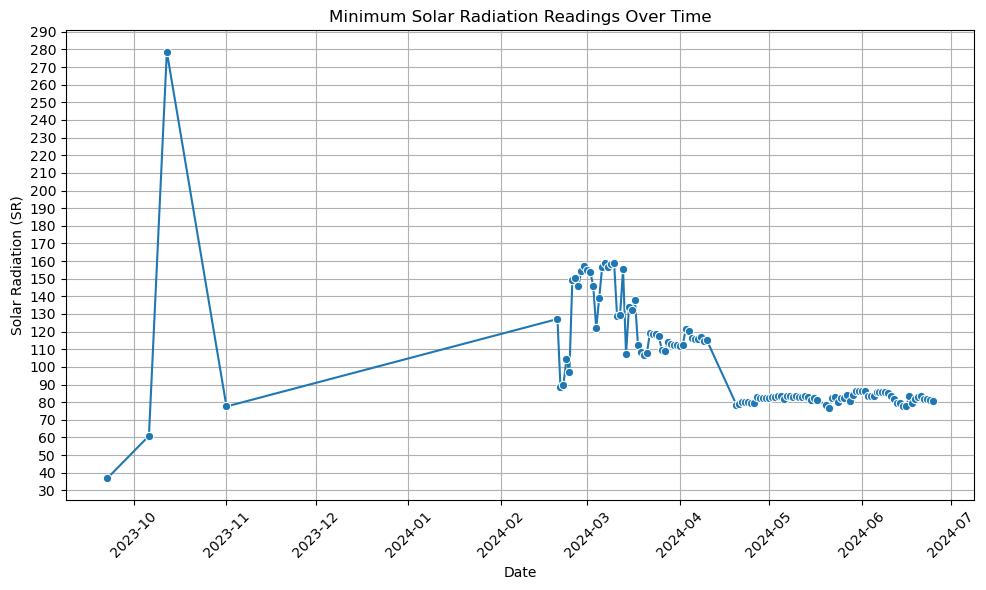

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Dates', y='SR', data=min_sr_per_date, marker='o')  # 'o' adds dots at each data point
plt.title('Minimum Solar Radiation Readings Over Time')
plt.xlabel('Date')
plt.ylabel('Solar Radiation (SR)')
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(10))
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

In [32]:
sr_weather = sr_weather.drop(columns = 'Datetime')
sr_weather

,Dates,Time,SR,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h),Sun Angle,Weather Type
573587,2023-09-22,17:26:14,133.17,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,0.0,21.0,39.0,28.689142,Cloudy
573660,2023-09-22,17:22:39,114.77,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,0.0,21.0,39.0,28.244278,Cloudy
573659,2023-09-22,17:29:27,152.49,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,0.0,21.0,39.0,29.083441,Sunny
573658,2023-09-22,17:22:33,118.77,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,0.0,21.0,39.0,28.231780,Cloudy
573657,2023-09-22,17:20:37,127.22,22.2,7.3,14.8,3.2,0.0,0.0,0.0,0.0,0.0,21.0,39.0,27.989267,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563028,2024-06-25,11:59:35,267.40,19.9,11.3,15.6,2.4,0.0,0.0,0.0,0.0,0.0,31.0,33.0,-1.571919,Sunny
563029,2024-06-25,23:57:25,81.29,19.9,11.3,15.6,2.4,0.0,0.0,0.0,0.0,0.0,31.0,33.0,39.308128,Cloudy
563030,2024-06-25,23:54:30,81.33,19.9,11.3,15.6,2.4,0.0,0.0,0.0,0.0,0.0,31.0,33.0,39.776803,Cloudy
563032,2024-06-25,23:57:08,81.42,19.9,11.3,15.6,2.4,0.0,0.0,0.0,0.0,0.0,31.0,33.0,39.353695,Cloudy


In [38]:
weather_0503_0611 = pd.read_csv("vancouver 2024-05-03 to 2024-06-11.csv")
weather_0503_0611

FileNotFoundError: [Errno 2] No such file or directory: 'vancouver 2024-05-03 to 2024-06-11.csv'